In [4]:
import numpy as np
import xarray as xr
import wavespectra
from wavespectra import read_swan, read_era5, read_ndbc, read_netcdf, read_wwm
import cmocean
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import plotly.graph_objects as go
#import numpy as np
from plotly.subplots import make_subplots
import inspect
#from sklearn_extra.cluster import CLARA
from pysofar.sofar import SofarApi
from pysofar.spotter import Spotter
import hdpgpc.GPI_HDP as hdpgp
from hdpgpc.get_data import compute_estimators_LDS

---

### Carga del archivo

In [5]:
# Cargar los datasets
ds_wave = xr.open_dataset("../data/NDBC/dir2017.nc")
ds_meteo = xr.open_dataset("../data/NDBC/meteo2017.nc")
ds_ocean = xr.open_dataset("../data/NDBC/ocean2017.nc")

FileNotFoundError: [Errno 2] No such file or directory: '/home/adrian.perez/Documents/OceanWave/HDP-GPC/hdpgpc/data/NDBC/dir2017.nc'

In [6]:
# Eliminar las dimensiones lat/lon (sólo hay un punto)
ds_wave = ds_wave.squeeze(["latitude", "longitude"])
ds_meteo = ds_meteo.squeeze(["latitude", "longitude"])
ds_ocean = ds_ocean.squeeze(["latitude", "longitude"])

In [7]:
# Convertir variables codificadas a NumPy arrays para evitar problemas de interpolación
for ds in [ds_meteo, ds_ocean]:
    for var in ds.data_vars:
        ds[var].data = ds[var].values

C:\Users\marco\AppData\Local\Temp\ipykernel_31500\4258022098.py:4: SerializationWarning:

Can't decode floating point timedelta to 's' without precision loss, decoding to 'ms' instead. To silence this warning use time_unit='ms' in call to decoding function.

C:\Users\marco\AppData\Local\Temp\ipykernel_31500\4258022098.py:4: SerializationWarning:

Can't decode floating point timedelta to 's' without precision loss, decoding to 'ns' instead. To silence this warning use time_unit='ns' in call to decoding function.



In [9]:
# Interpolar viento y profundidad al tiempo del espectro
meteo_interp = ds_meteo.interp(time=ds_wave.time)
ocean_interp = ds_ocean.interp(time=ds_wave.time)

# Combinar todo en un nuevo dataset
ds = ds_wave.assign({
    "wspd": meteo_interp["wind_spd"],
    "wdir": meteo_interp["wind_dir"],
    "dpt": ocean_interp["depth"]
})


In [10]:
ds

<xarray.Dataset> Size: 12MB
Dimensions:                (time: 8694, frequency: 47)
Coordinates:
  * time                   (time) datetime64[ns] 70kB 2017-01-01 ... 2017-12-...
  * frequency              (frequency) float32 188B 0.02 0.0325 ... 0.465 0.485
    latitude               float32 4B 33.44
    longitude              float32 4B -77.76
Data variables:
    spectral_wave_density  (time, frequency) float32 2MB ...
    mean_wave_dir          (time, frequency) float64 3MB ...
    principal_wave_dir     (time, frequency) float64 3MB ...
    wave_spectrum_r1       (time, frequency) float32 2MB ...
    wave_spectrum_r2       (time, frequency) float32 2MB ...
    wspd                   (time) float64 70kB 7.9 7.1 7.4 ... 11.3 10.8 10.4
    wdir                   (time) float64 70kB 274.0 258.0 270.0 ... 20.0 16.0
    dpt                    (time) float64 70kB 1.0 1.0 1.0 1.0 ... nan nan nan
Attributes:
    institution:  NOAA National Data Buoy Center and Participators in Data As...
    url:          http://dods.ndbc.noaa.gov
    quality:      Automated QC checks with manual editing and comprehensive m...
    conventions:  COARDS
    station:      41013
    comment:      Frying Pan Shoals, NC
    location:     33.441 N 77.764 W

In [3]:
# Carga de los datos en formato no direccional
ds = read_ndbc('../data/NDBC/dir2017.nc', directional=False).isel(lat=0, lon=0)
ds

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 8694, freq: 47)
Coordinates:
  * time     (time) datetime64[ns] 70kB 2017-01-01 ... 2017-12-31T23:00:00
  * freq     (freq) float32 188B 0.02 0.0325 0.0375 0.0425 ... 0.445 0.465 0.485
    lat      float32 4B 33.44
    lon      float32 4B -77.76
Data variables:
    efth     (time, freq) float32 2MB dask.array<chunksize=(8694, 47), meta=np.ndarray>

In [21]:
data = ds.efth.values
freq = ds.freq.values
data = pd.DataFrame(data, columns=freq)
data = data.to_numpy()
data = data[:, :, np.newaxis]
data = data.astype(np.float64)
print("Shape of the data: ")
print(data.shape)
num_samples, num_obs_per_sample, num_outputs = data.shape

Shape of the data: 
(8744, 47, 1)


Shape of hs: (8744, 1)
How much spectra falls in the range 0.5-3.0 Hs: 7698


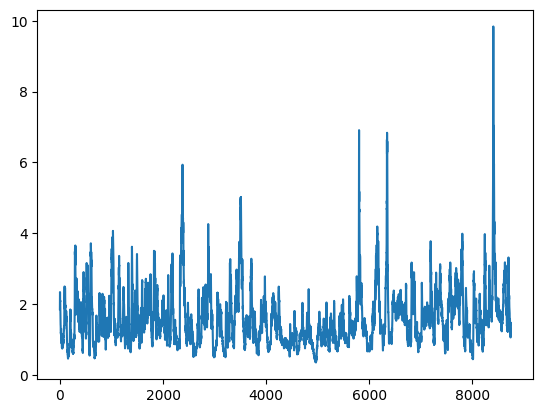

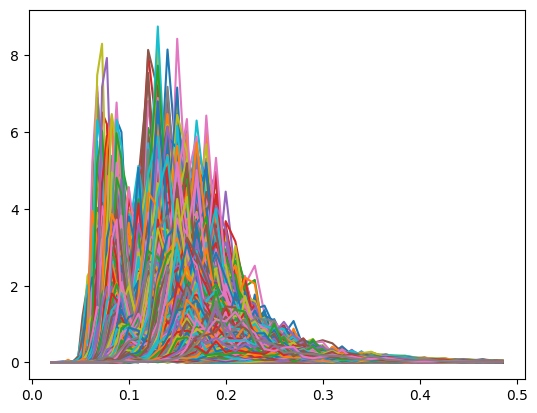

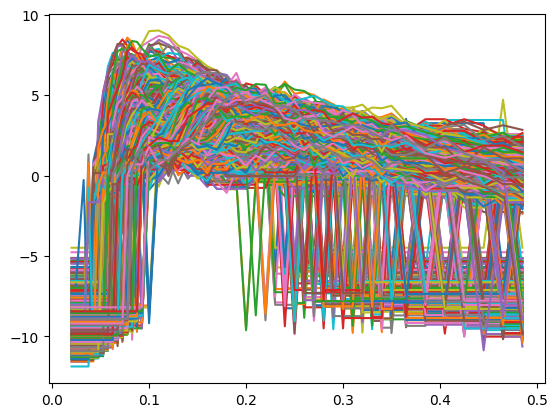

In [23]:
#Here we are going to compute the Heighs and try to filter following Hamiltons rule.
interv = np.repeat(freq[1]-freq[0], num_obs_per_sample)[:, np.newaxis]
hs = 4 * np.sqrt(data[:,:,0] @ interv)
print("Shape of hs: "+str(hs.shape))
plt.plot(hs)
chosen_indexes = np.where((hs > 0.5) & (hs < 2.5))[0]
#chosen_indexes = np.arange(0, num_samples)
print("How much spectra falls in the range 0.5-3.0 Hs: " + str(chosen_indexes.shape[0]))
plt.show()
plt.plot(freq, data[:,:,0][chosen_indexes].T)
plt.show()
lognorm_data = np.log(data + 1e-6) - np.mean(np.log(data+ 1e-6), axis=1)[:,np.newaxis,:]
plt.plot(freq, lognorm_data[:,:,0][chosen_indexes].T)
plt.show()

In [24]:
#Select indexes
data = data[chosen_indexes]

chosen_indexes = np.where((freq > 0.04) & (freq <= 0.35))[0]

data = data[:, chosen_indexes, :]
#Select indexes
freq = freq[chosen_indexes]

num_samples, num_obs_per_sample, num_outputs = data.shape

print("Shape of the data: ")
print(data.shape)

print("Shape of the frequencies: ")
print(freq.shape)

Shape of the data: 
(7698, 37, 1)
Shape of the frequencies: 
(37,)


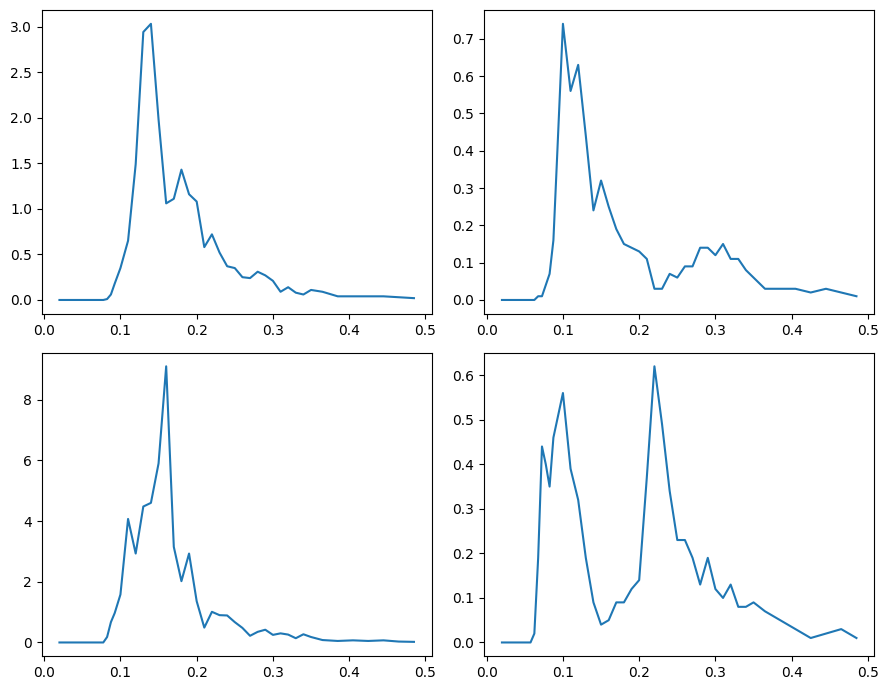

In [5]:
# Se grafican cuatro espectros no direccionales para ver si coinciden con lo visto hasta ahora
fig, axs = plt.subplots(2, 2, figsize=(9, 7))

freq = ds.freq.values

axs[0, 0].plot(freq, ds.efth.isel(time=472).values)

axs[0, 1].plot(freq, ds.efth.isel(time=25).values)

axs[1, 0].plot(freq, ds.efth.isel(time=1039).values)

axs[1, 1].plot(freq, ds.efth.isel(time=5923).values)

plt.tight_layout()
plt.show()

In [25]:
# Espectros direccionales
# Carga de los datos en formato no direccional
ds = read_ndbc('../data/NDBC/dir2023.nc', weight_coeff = True).isel(lat=0, lon=0)
new_dirs = np.linspace(0, 360, 37)  # Cada 10° incluyendo 360°
ds = ds.interp(dir=new_dirs, kwargs={"fill_value": "extrapolate"})
ds

<xarray.Dataset> Size: 122MB
Dimensions:  (time: 8744, freq: 47, dir: 37)
Coordinates:
  * time     (time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-31T23:00:00
  * freq     (freq) float32 188B 0.02 0.0325 0.0375 0.0425 ... 0.445 0.465 0.485
    lat      float32 4B 33.44
    lon      float32 4B -77.76
  * dir      (dir) float64 296B 0.0 10.0 20.0 30.0 ... 330.0 340.0 350.0 360.0
Data variables:
    efth     (time, freq, dir) float64 122MB dask.array<chunksize=(8744, 47, 37), meta=np.ndarray>

### Integrar

In [24]:
ds.spec.oned??

```python
def oned(self, skipna=True):
"""Returns the one-dimensional frequency spectra.

Direction dimension is dropped after integrating.

Args:
    - skipna (bool): choose it to skip nans when integrating spectra.
      This is the default behaviour for sum() in DataArray. Notice it
      converts masks, where the entire array is nan, into zero.

"""
    if self.dir is not None:
        dsout = self.dd * self._obj.sum(dim=attrs.DIRNAME, skipna=skipna)
    else:
        dsout = self._obj.copy(deep=True)
    set_spec_attributes(dsout)
    return dsout
```

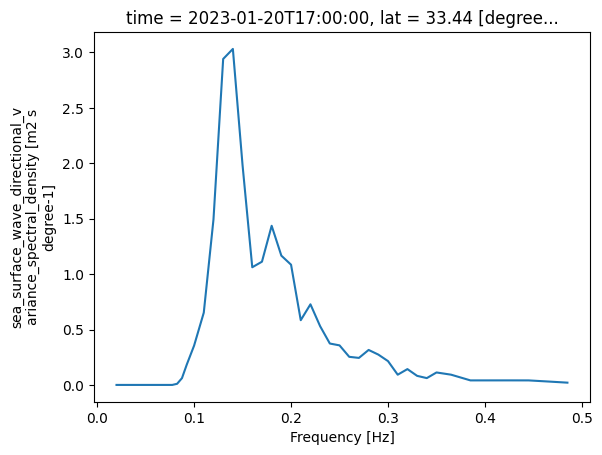

In [20]:
ds2 = ds.spec.oned()
ds2.isel(time=472).plot()

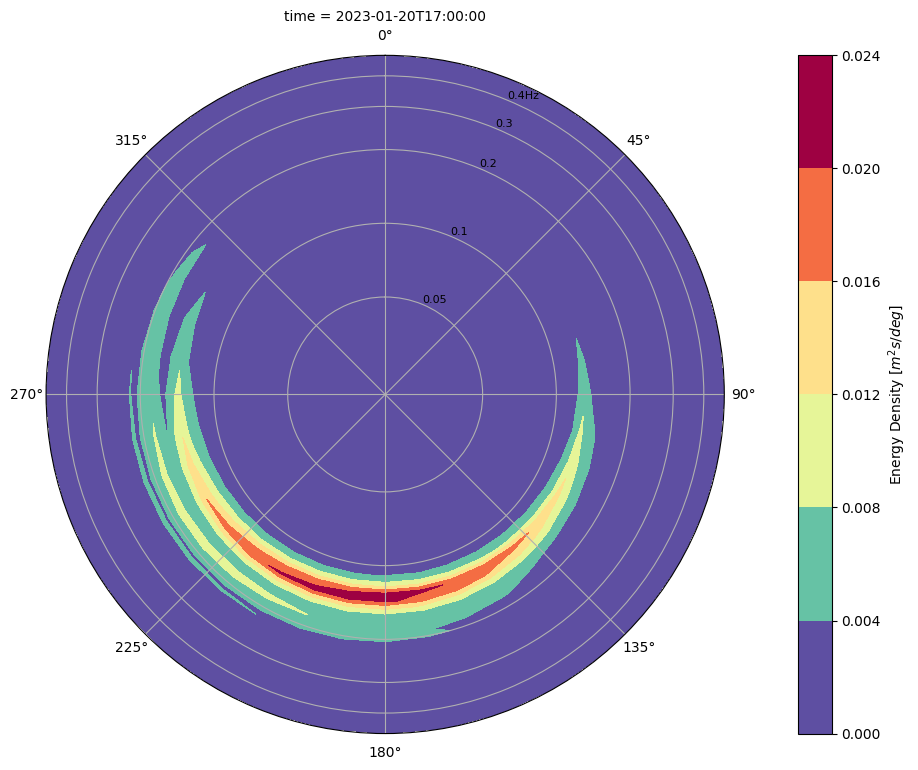

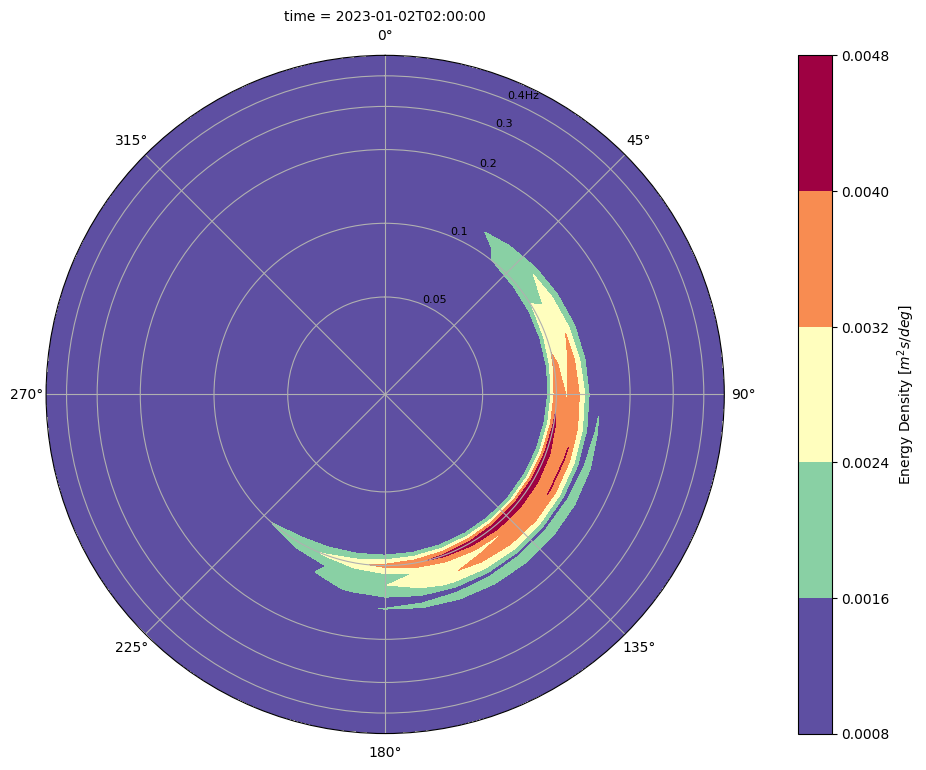

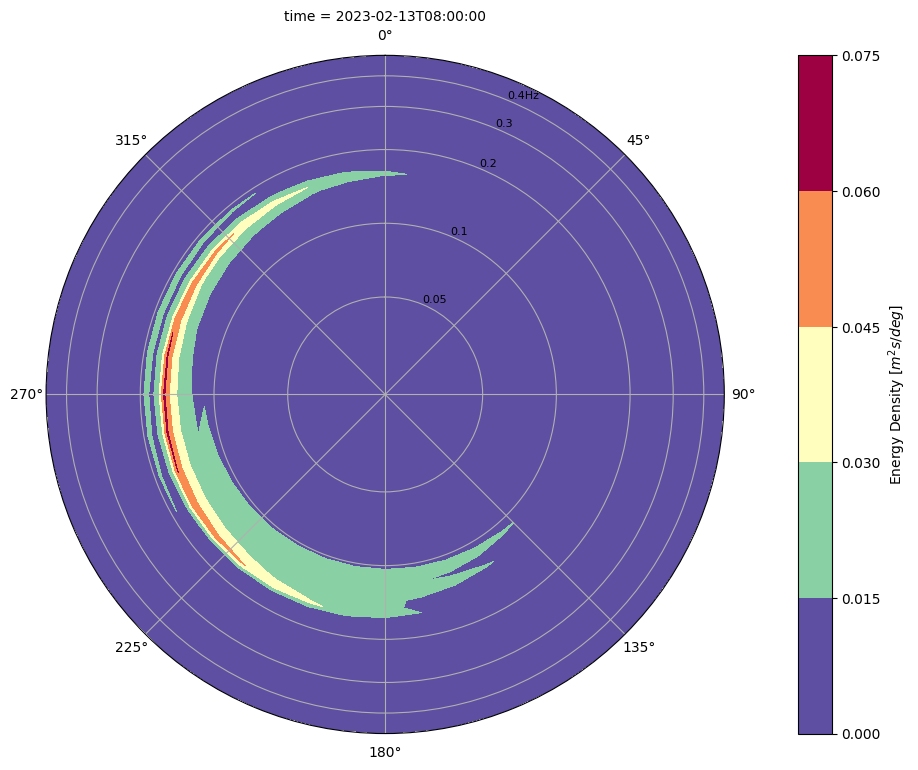

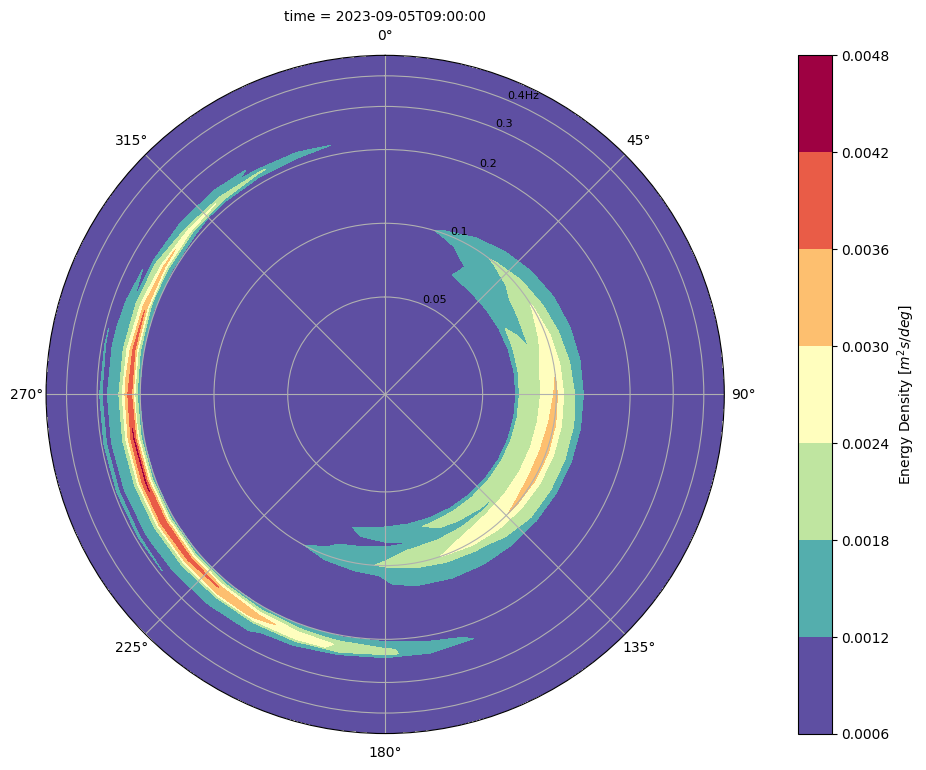

In [46]:
times = [472, 25, 1039, 5923] 

for i, ax in enumerate(axs.flat): 
    ds2 = ds.isel(time=[times[i]])  
    ds2.spec.plot(
        normalised=False,
        col="time",
        figsize=(15, 8),
        cmap="Spectral_r",
    )

---

In [60]:
def plot_spectral_grid(ds, time_indices):
    
    angle_offsets = {
    0: 0,   # Desplazamiento para 0°
    45: 0.02,  # Desplazamiento para 45°
    90: 0.15,  # Desplazamiento para 90°
    135: 0.25,  # Desplazamiento para 135°
    180: 0.25, # Desplazamiento para 180°
    225: 0.25, # Desplazamiento para 225°
    270: 0.15, # Desplazamiento para 270°
    315: 0   # Desplazamiento para 315°
    }
    
    num_plots = len(time_indices)
    cols = min(2, num_plots)
    rows = (num_plots // cols) + (num_plots % cols > 0)
    
    fig = make_subplots(rows=rows, cols=cols, subplot_titles=[f'Time {t}' for t in time_indices],
                        specs=[[{'type': 'surface'}] * cols for _ in range(rows)])
    
    for idx, time in enumerate(time_indices):
        row, col = divmod(idx, cols)
        ds2 = ds.isel(time=time)
        ds2 = ds2.sel(freq=(ds2.freq >= 0.04) & (ds2.freq <= 0.4))
        ds2 = ds2.sel(freq=(ds2.freq >= 0.04) & (ds2.freq <= 0.4))

        frequencies = ds2.freq.values
        directions = np.radians(ds2.dir.values)
        energy_spectral = ds2.efth.values
   
        Theta, Freq = np.meshgrid(frequencies, directions)
        X = Theta * np.cos(Freq)
        Y = Theta * np.sin(Freq)
        Z = energy_spectral.T


        surface = go.Surface(
            x=X, 
            y=-Y, 
            z=Z, 
            colorscale='Spectral_r', 
            opacity=0,            # Hace que la superficie sea completamente invisible
            showlegend=False,     # Oculta la leyenda
            showscale=False,      # No mostrar la barra de escala
        )


        fig.add_trace(surface, row=row+1, col=col+1)
        
        # Círculos internos y bordes
        max_frequency = np.max(frequencies)

        # Definir los radios como una fracción del valor máximo
        circle_radii = [0.75 * max_frequency, 0.5 * max_frequency, 0.25 * max_frequency]

        # Graficar los círculos con los nuevos radios ajustados
        for freq in circle_radii:
            circle_x = freq * np.cos(np.linspace(0, 2 * np.pi, 100))
            circle_y = freq * np.sin(np.linspace(0, 2 * np.pi, 100))
            fig.add_trace(go.Scatter3d(
                x=circle_x, 
                y=circle_y, 
                z=np.zeros_like(circle_x), 
                mode='lines',
                line=dict(color='black', width=0.5, dash='dash'),
                showlegend=False
            ), row=row+1, col=col+1)
        # Bordes de la circunferencia
        border_x = 0.4 * np.cos(np.linspace(0, 2 * np.pi, 100))
        border_y = 0.4 * np.sin(np.linspace(0, 2 * np.pi, 100))
        fig.add_trace(go.Scatter3d(
            x=border_x, 
            y=border_y, 
            z=np.zeros_like(border_x), 
            mode='lines',
            line=dict(color='black', width=1)
        ), row=row+1, col=col+1)
        
        # Graficar radios y etiquetas de dirección (cada 30 grados)
        for angle in range(0, 360, 45):
            rad = np.radians(-angle)
            x = 0.4 * np.cos(rad)
            y = 0.4 * np.sin(rad)
                
            fig.add_trace(go.Scatter3d(
                x=[0, x], 
                y=[0, y], 
                z=[0, 0], 
                mode='lines', 
                line=dict(color='black', width=0.5, dash='dash'), 
                showlegend=False
            ), row=row+1, col=col+1)
            fig.add_trace(go.Scatter3d(
                x=[x], 
                y=[y], 
                z=[0], 
                mode='text', 
                text=[f"{angle}°"], 
                showlegend=False,
                textposition='bottom center'
            ), row=row+1, col=col+1)
    
    fig.update_layout(
        height=800 * rows,  # Aumentar tamaño de las figuras
        width=600 * cols,  # Aumentar tamaño de las figuras
        title_text='Spectral Energy Distribution',
        showlegend=False,
    )
    
    for i in range(1, num_plots + 1):
        fig.update_scenes(
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            zaxis=dict(visible=False),
            bgcolor='rgba(0,0,0,0)',  # Fondo transparente
            row=(i - 1) // cols + 1,
            col=(i - 1) % cols + 1
        )
    
    fig.show()

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_spectral_grid_static(ds, time_indices):
    # Definición de los desplazamientos de ángulo para las etiquetas
    angle_offsets = {
        0: 0, 45: 0.02, 90: 0.15, 135: 0.25, 180: 0.25,
        225: 0.25, 270: 0.15, 315: 0
    }
    
    num_plots = len(time_indices)
    cols = min(2, num_plots)
    rows = (num_plots // cols) + (num_plots % cols > 0)

    # Configuración de la figura y los subgráficos
    fig = plt.figure(figsize=(12, 8))
    axes = [fig.add_subplot(rows, cols, idx + 1, projection='3d') for idx in range(num_plots)]
    
    for idx, time in enumerate(time_indices):
        ax = axes[idx]
        ds2 = ds.isel(time=time)
        ds2 = ds2.sel(freq=(ds2.freq >= 0.04) & (ds2.freq <= 0.4))

        frequencies = ds2.freq.values
        directions = np.radians(ds2.dir.values)
        energy_spectral = ds2.efth.values

        # Crear la malla de frecuencias y direcciones
        Theta, Freq = np.meshgrid(frequencies, directions)
        X = Theta * np.cos(Freq)
        Y = Theta * np.sin(Freq)
        Z = energy_spectral.T
        
        # Graficar la superficie
        ax.contour(X, Y, Z, 50, cmap='Spectral_r')

        # Círculos internos y bordes
        max_frequency = np.max(frequencies)
        circle_radii = [0.75 * max_frequency, 0.5 * max_frequency, 0.25 * max_frequency]

        for freq in circle_radii:
            circle_x = freq * np.cos(np.linspace(0, 2 * np.pi, 100))
            circle_y = freq * np.sin(np.linspace(0, 2 * np.pi, 100))
            ax.plot(circle_x, circle_y, zs=0, color='black', linewidth=0.5, linestyle='--')

        # Bordes de la circunferencia
        border_x = 0.4 * np.cos(np.linspace(0, 2 * np.pi, 100))
        border_y = 0.4 * np.sin(np.linspace(0, 2 * np.pi, 100))
        ax.plot(border_x, border_y, zs=0, color='black', linewidth=1)

        # Graficar radios y etiquetas de dirección (cada 45 grados)
        for angle in range(0, 360, 45):
            rad = np.radians(-angle)
            x = 0.4 * np.cos(rad)
            y = 0.4 * np.sin(rad)
            ax.plot([0, x], [0, y], zs=[0, 0], color='black', linewidth=0.5, linestyle='--')
            #ax.text(x * 1.05, y * 1.05, 0, f'{angle}°', color='black', fontsize=10, ha='center')

        # Título para cada gráfico
        ax.set_title(f"Time {time}")
        ax.grid(False)
        ax.set_axis_off()
        # Ocultar los ticks y etiquetas de los ejes
        ax.set_xticks([])  # Sin ticks en el eje X
        ax.set_yticks([])  # Sin ticks en el eje Y
        ax.set_zticks([])
    
    plt.tight_layout()
    plt.show()



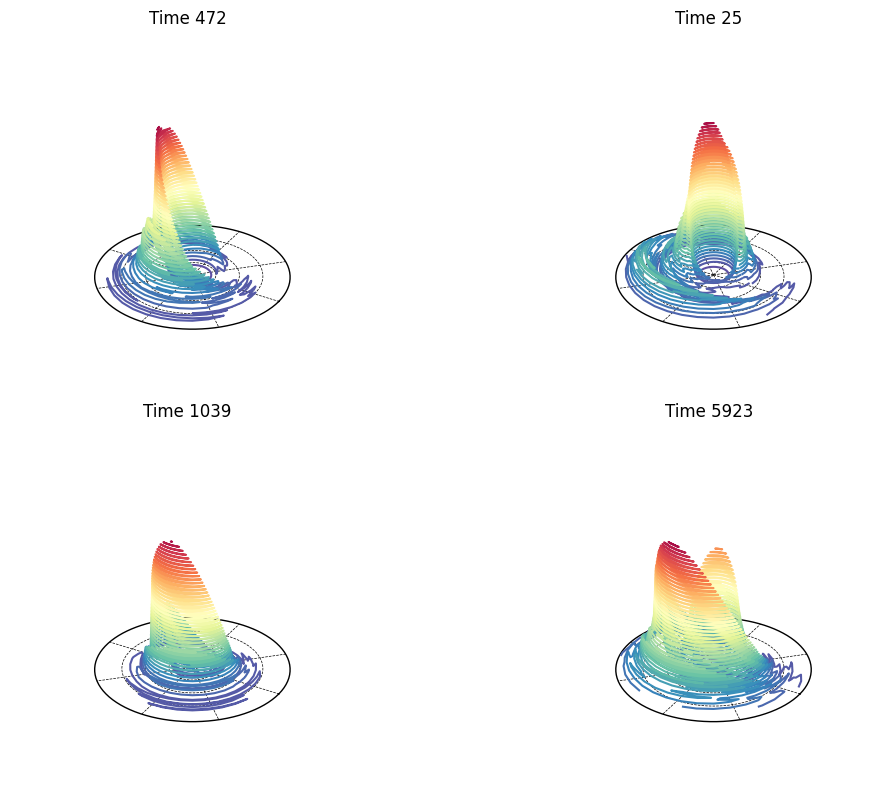

In [103]:
plot_spectral_grid_static(ds, [472, 25, 1039, 5923])

---

### Clasificación CLARA

In [199]:
data_df = pd.DataFrame(np.squeeze(data[:, 0:len(freq), :], axis=-1))

In [193]:
def clara_plot(nc, data_df, ano):

    clara = CLARA(n_clusters=nc, random_state=42, max_iter=10000)
    clara.fit(data_df)

    exs_clara = []

    labels = clara.labels_
    centroids = clara.cluster_centers_
    n_clusters = clara.n_clusters

    centroides_clara = centroids
    
    #data_date['cluster'] = clara.labels_
    #dict_grupos[ano] = data_date[['date', 'cluster']]

    num_cols = int(np.ceil(np.sqrt(nc)))
    
    if(num_cols > 4):
        num_cols = 4
    
    num_rows = int(np.ceil(nc / num_cols))

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(13, 25), squeeze=False)
    axes = axes.flatten()

    for cluster_num in range(n_clusters):

        cluster_points = data_df[labels == cluster_num]
        ax = axes[cluster_num]

        exs_clara.append(freq)
        for row in cluster_points.values:
            ax.plot(freq, row, color='darkorange', alpha=0.1)

        ax.plot(freq, centroids[cluster_num, :], color='black', linewidth=2, label=f'Centroide Cluster {cluster_num}')
        num_ondas = cluster_points.shape[0]
        ax.set_title(f'Cluster {cluster_num} - {num_ondas}')


    for ax in fig.get_axes():
                ax.set_ylim(np.min(data_df)-0.5, np.max(data_df) + 0.5)
                ax.set_xticks(np.arange(0.05,0.4,0.05))

    for j in range(len(axes)):
        if j >= nc:
            axes[j].axis('off')

    plt.tight_layout()
    plt.show()
    
    return centroides_clara, exs_clara

In [183]:
def gap_statistic(X, K_range=range(2, 50), n_references=10):
    """
    Calcula el número óptimo de clústeres usando el método del Gap Statistic.

    Parámetros:
    - X: Datos a clusterizar (numpy array o DataFrame).
    - K_range: Rango de valores de k a evaluar.
    - n_references: Número de conjuntos de datos aleatorios para la comparación.

    Retorna:
    - Mejor valor de k basado en el máximo Gap Statistic.
    """
    gaps = []
    
    for k in K_range:
        # CLARA sobre datos base
        clara = CLARA(n_clusters=k, random_state=42).fit(X)
        inercia_real = clara.inertia_

        # Datos aleatorios
        reference_inertia = []
        for i in range(n_references):
            random_data = np.random.uniform(low=X.min(axis=0), high=X.max(axis=0), size=X.shape)
            clara.fit(random_data)
            reference_inertia.append(clara.inertia_)          
            
        gap = np.log(np.mean(reference_inertia)) - np.log(inercia_real)
        gaps.append(gap)

    # Seleccionar el k con el mayor Gap
    k_optimo = np.argmax(gaps) + K_range[0]

    return k_optimo, gaps

### 2023

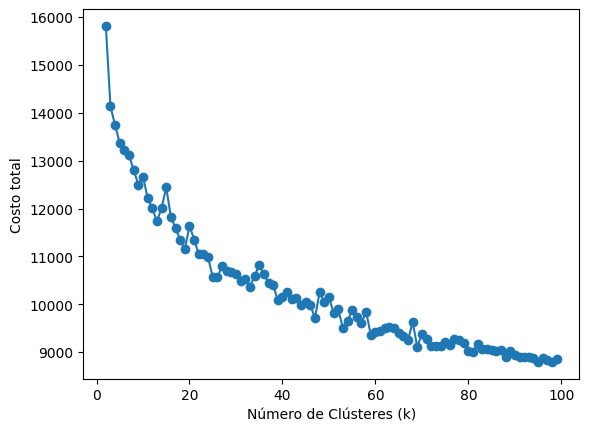

In [184]:
costs = []

for k in range(2, 100):
    clara = CLARA(n_clusters=k, random_state=42)
    clara.fit(data_df)
    costs.append(clara.inertia_)

plt.plot(range(2, 100), costs, marker='o')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Costo total')
plt.show()

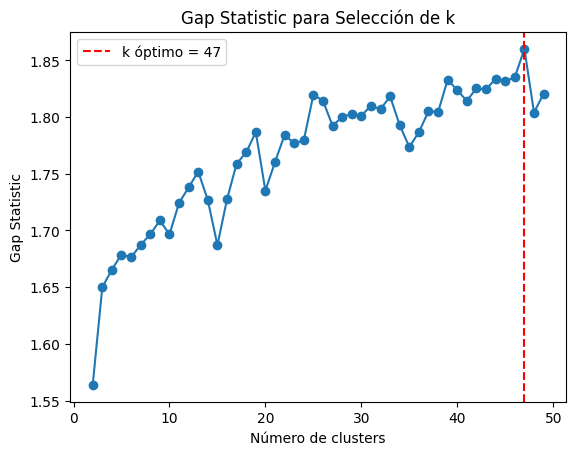

El número óptimo de clústeres según el Gap Statistic es: 47


In [185]:
k_optimo, gaps = gap_statistic(data_df)

plt.plot(range(2, 50), gaps, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Gap Statistic')
plt.title('Gap Statistic para Selección de k')
plt.axvline(x=k_optimo, linestyle='--', color='red', label=f'k óptimo = {k_optimo}')
plt.legend()
plt.show()

print(f"El número óptimo de clústeres según el Gap Statistic es: {k_optimo}")

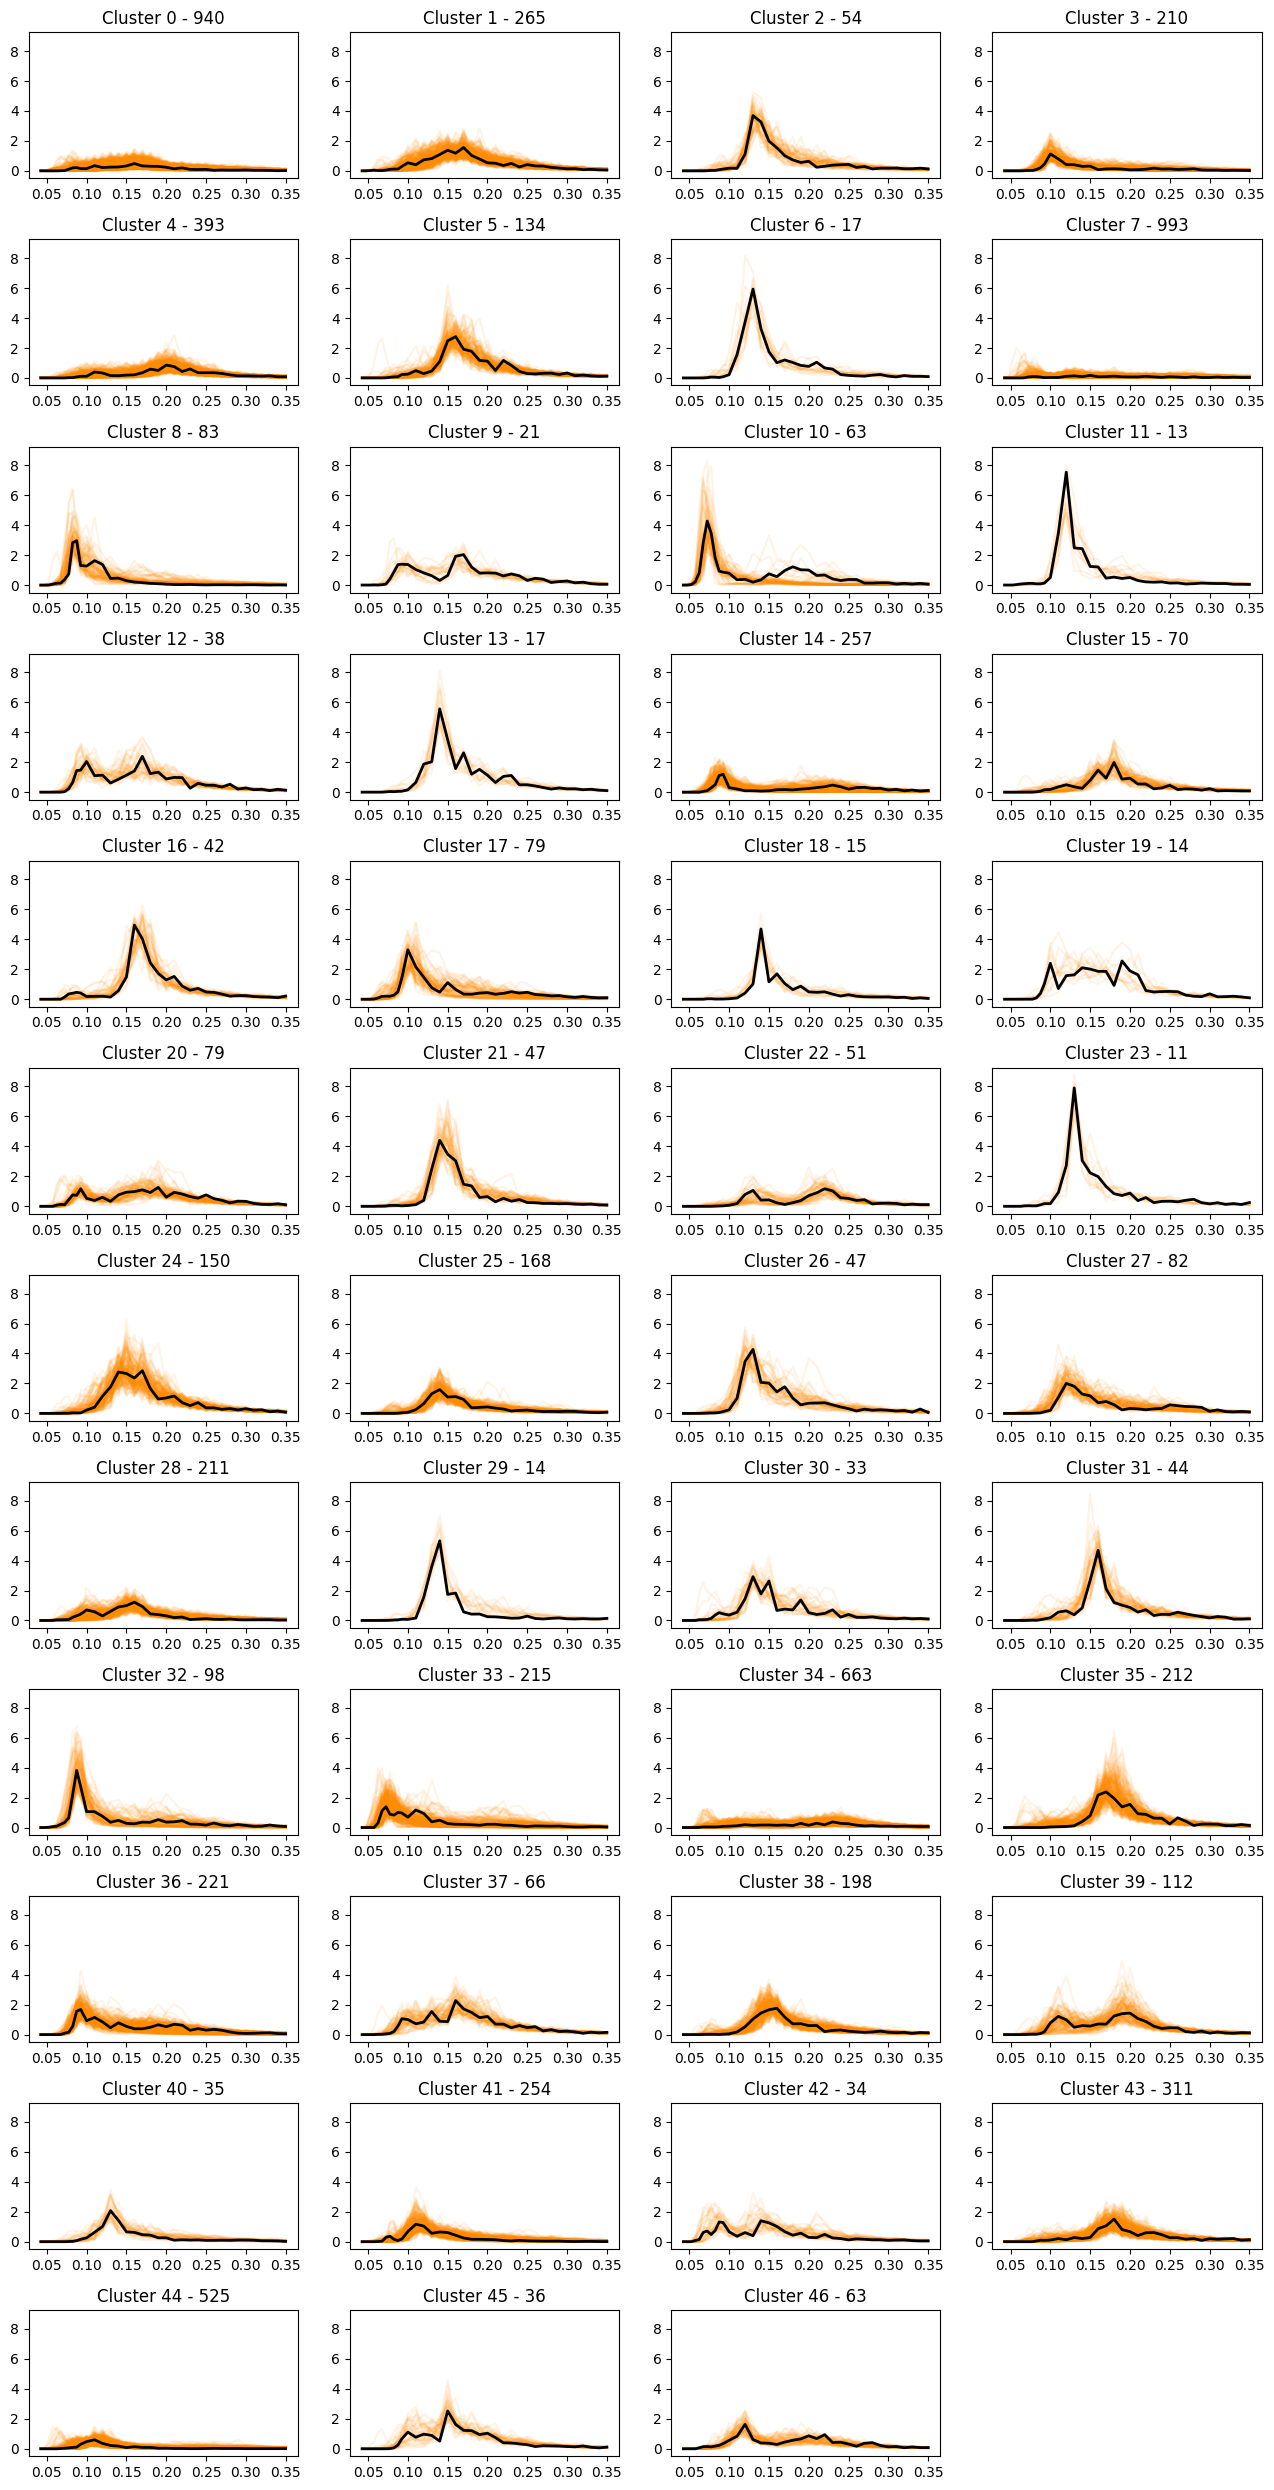

In [194]:
c24, x24 = clara_plot(47, data_df, 2023)

### 2024

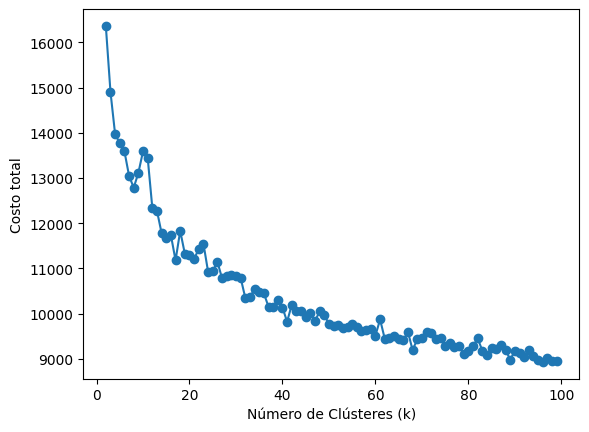

In [200]:
costs = []

for k in range(2, 100):
    clara = CLARA(n_clusters=k, random_state=42)
    clara.fit(data_df)
    costs.append(clara.inertia_)

plt.plot(range(2, 100), costs, marker='o')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Costo total')
plt.show()

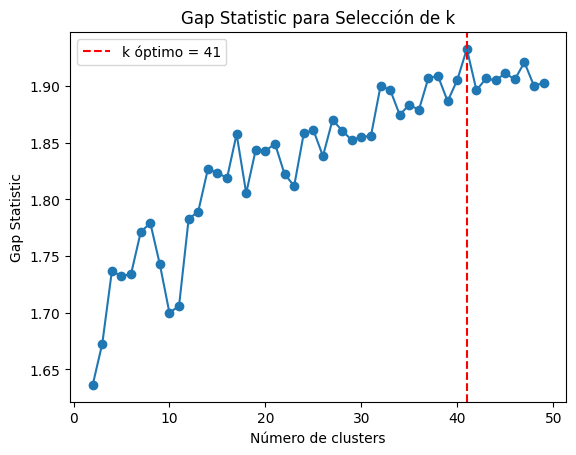

El número óptimo de clústeres según el Gap Statistic es: 41


In [201]:
k_optimo, gaps = gap_statistic(data_df)

plt.plot(range(2, 50), gaps, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Gap Statistic')
plt.title('Gap Statistic para Selección de k')
plt.axvline(x=k_optimo, linestyle='--', color='red', label=f'k óptimo = {k_optimo}')
plt.legend()
plt.show()

print(f"El número óptimo de clústeres según el Gap Statistic es: {k_optimo}")

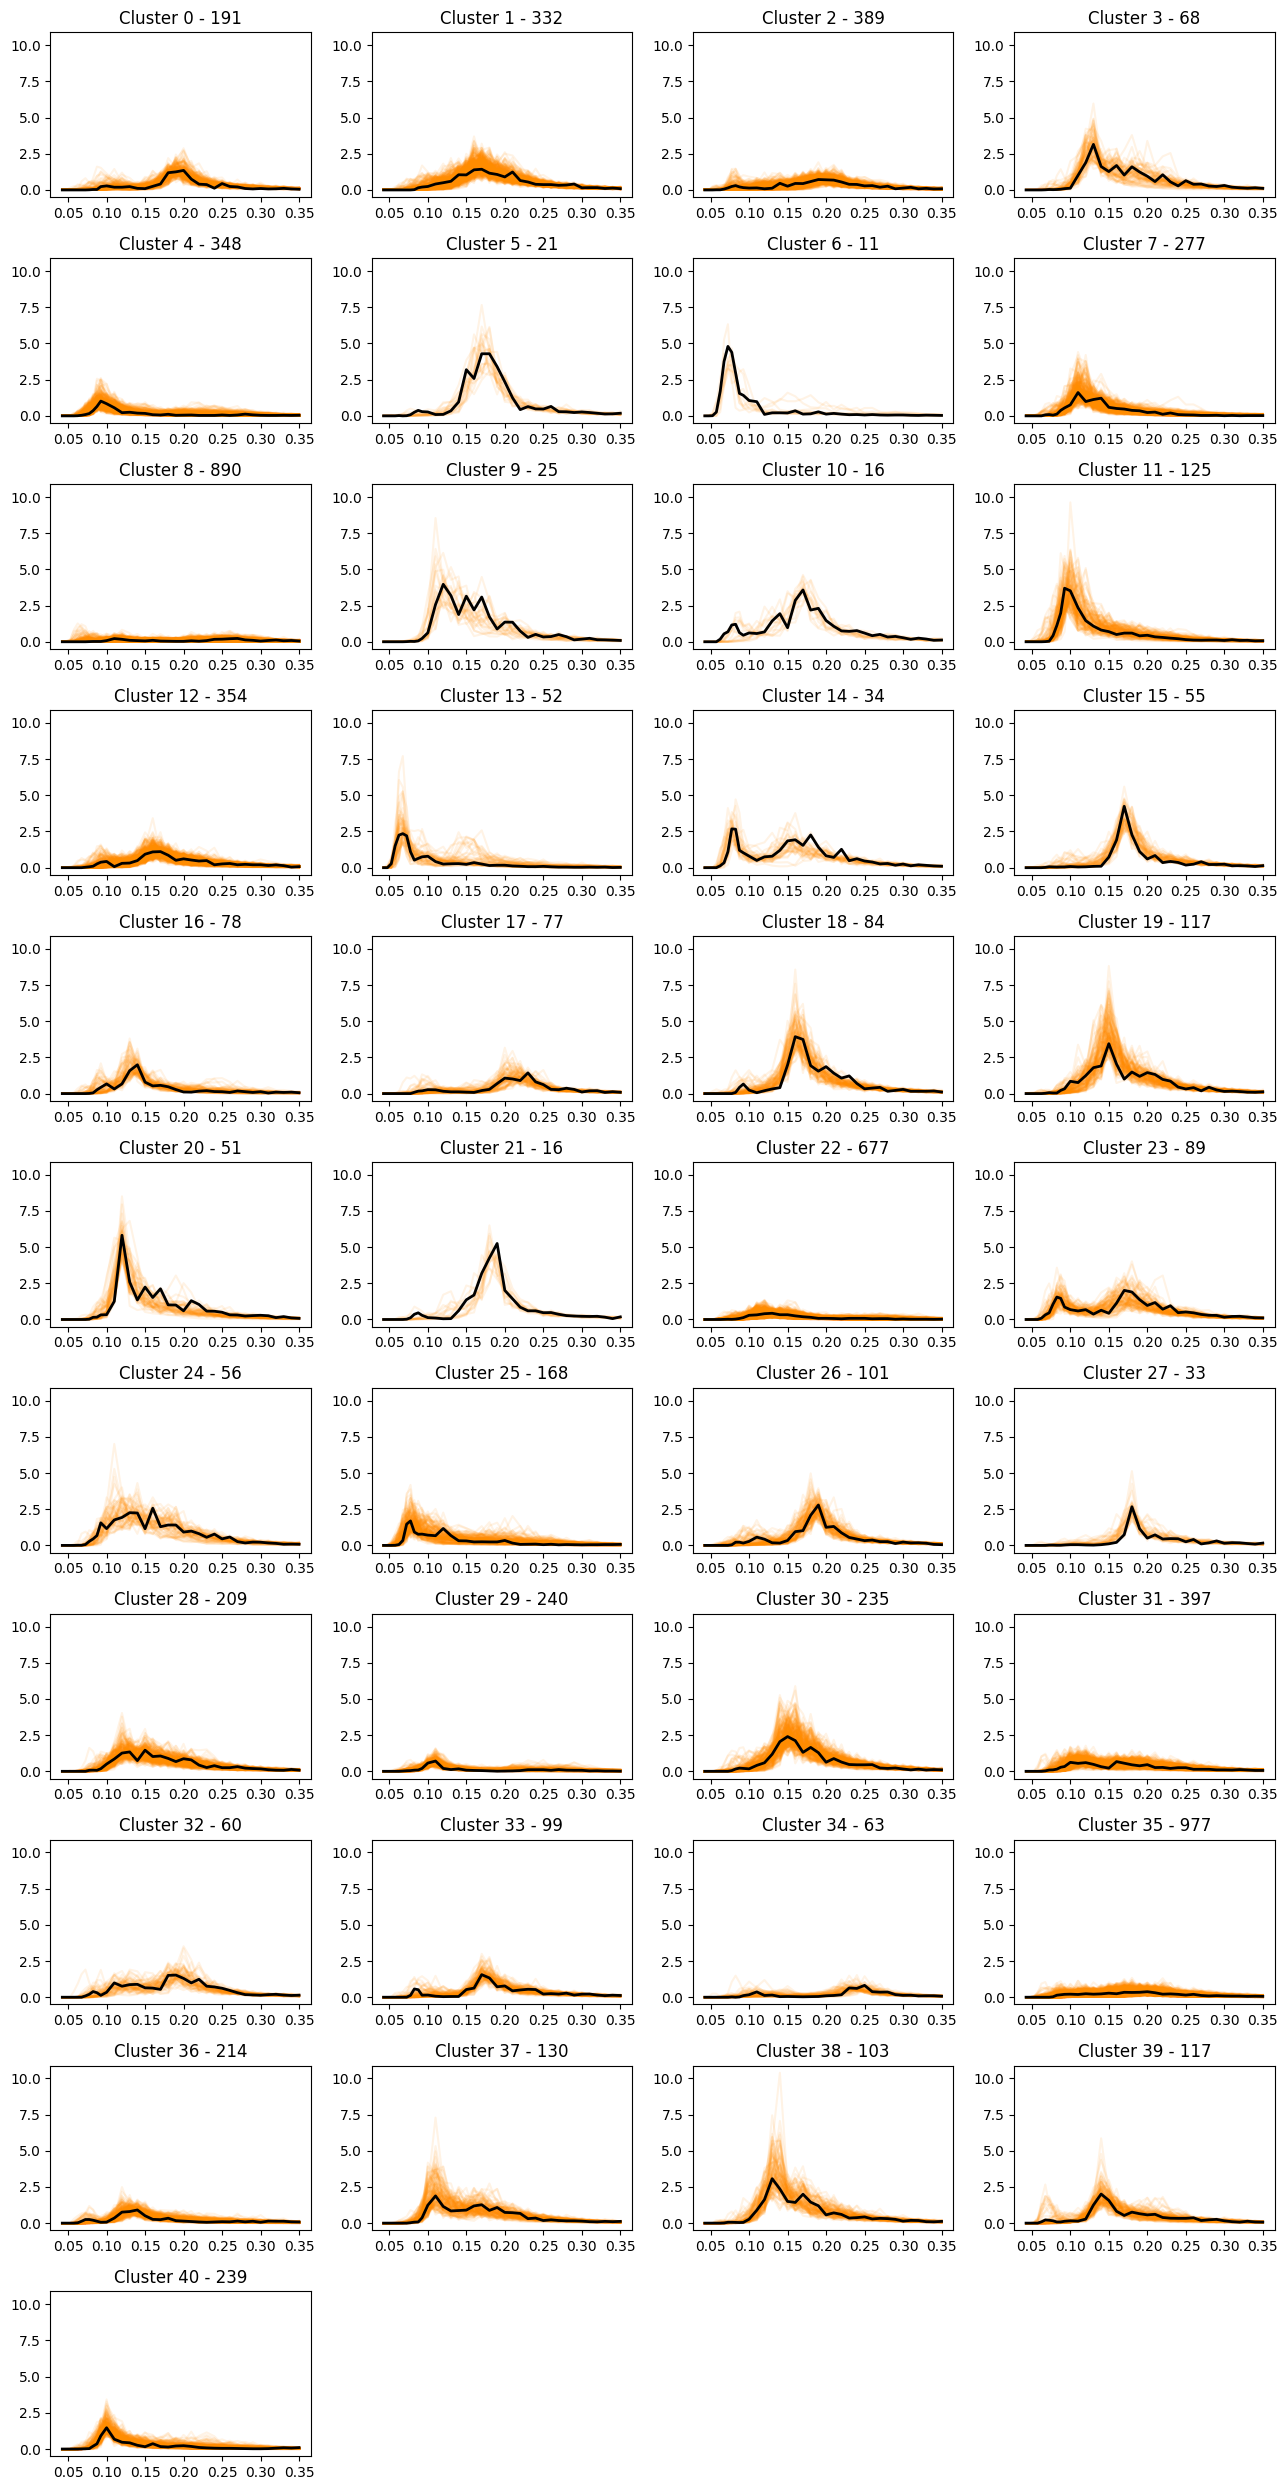

In [202]:
c24, x24 = clara_plot(41, data_df, 2024)

### Modelo Gaussiano

### 2023

In [25]:
std, std_dif, bound_sigma, bound_gamma = compute_estimators_LDS(data, n_f=num_samples-1)
#Seem like these estimators are so big for this data, let's reduce them
std = std * 0.2
std_dif = std_dif * 0.1
bound_sigma = (std * 1e-7, std * 1e-1)
bound_gamma = (std_dif * 1e-9, std_dif * 1e-1)

print("Final sigma:", std)
print("Final gamma:", std_dif)
print("Final sigma bound:", bound_sigma)
print("Final gamma bound:", bound_gamma)

Sigma estimated: 0.19896863927186928
Gamma estimated: 0.19896863927186928
Final sigma: 0.03979372785437386
Final gamma: 0.01989686392718693
Final sigma bound: (3.979372785437385e-09, 0.003979372785437386)
Final gamma bound: (1.989686392718693e-11, 0.001989686392718693)


In [26]:
M = 2
sigma = [std * 1.0] * M
gamma = [std_dif * 1.0] * M
outputscale_ = 1.0
ini_lengthscale = 1e-2
bound_lengthscale = (1e-7, 5e-1)
samples = [0, num_obs_per_sample]
l, L = samples[0], samples[1]
# x_basis has to have the same dimension structure as data[0], in this case (171,1) but it could be (n_inducing_points, 1).
x_basis = np.atleast_2d(freq).T
x_train = np.atleast_2d(freq).T
print(x_train.shape)
#If x_basis is wanted to be smaller than the observations length, then the inducing points approach can be applied setting this parameter to True.
inducing_points = False
#Choose if warp is going to be applied. (In the most recent version is optimized to work with online inference, but it can be used in offline as an additional step at the end of the clustering).
warp = False
#Warp priors
noise_warp = std * 0.1
bound_noise_warp = (noise_warp * 0.1, noise_warp * 0.2)
#Warp time indexes
x_basis_warp = np.atleast_2d(np.arange(freq[0], freq[-1], freq.shape[0]/2.0, dtype=np.float64)).T

(37, 1)


In [ ]:
sw_gp = hdpgp.GPI_HDP(x_basis=x_basis, x_basis_warp=x_basis_warp, n_outputs=1,
                          ini_lengthscale=ini_lengthscale, bound_lengthscale=bound_lengthscale,
                          ini_gamma=gamma, ini_sigma=sigma, ini_outputscale=outputscale_, noise_warp=noise_warp,
                          bound_sigma=bound_sigma, bound_gamma=bound_gamma, bound_noise_warp=bound_noise_warp,
                          verbose=False, max_models=100, inducing_points=inducing_points, reestimate_initial_params=False,
                          n_explore_steps=10, free_deg_MNIV=20)

x_trains = np.array([x_train] * num_samples)
sw_gp.include_batch(x_trains, data[:num_samples,:,[0]])

------ HDP Hyperparameters ------
gamma: 0.8
transAlpha: 0.8
startAlpha: 0.8
kappa: 0.0
---------------------------------
Group responsability estimated: [7698]
---Kernel estimated---
0.618**2 * RBF(length_scale=0.00944) + WhiteKernel(noise_level=0.00362)

-----------Lead 1-----------
Step 1/10- Trying to divide: 0 with beat 5518
---Kernel estimated---
0.748**2 * RBF(length_scale=0.00508) + WhiteKernel(noise_level=0.00372)
Sum resp_temp: [7607   91]
Q_em: -148233.06, Q_lat: -760462.63, Elbo_linear: -2442.76, Elbo_LDS: -4643.60

-----------Lead 1-----------

   -----------Model 1-----------

   -----------Model 2-----------
>>> Q_all_loop -------
Sum resp_temp: [7607   91]
Q_em: -148233.06, Q_lat: -760462.63, Elbo_linear: -2442.76, Elbo_LDS: -4643.60
Sum resp_temp: [7476  227]
Q_em: -145382.69, Q_lat: -737171.35, Elbo_linear: -11353.07, Elbo_LDS: -4788.23
Sum resp_temp: [7476  227]
Q_em: -145382.69, Q_lat: -737171.35, Elbo_linear: -11353.07, Elbo_LDS: -4788.23
ELBO_reduction: 17086.6971

Sum resp_temp: [6648 1055]
Q_em: -135291.76, Q_lat: -626150.36, Elbo_linear: -22302.74, Elbo_LDS: -5448.03
ELBO_reduction: 241.64598792069592

-----------Lead 1-----------

   -----------Model 1-----------

   -----------Model 2-----------
>>> Q_all_loop -------
Sum resp_temp: [6648 1055]
Q_em: -135291.76, Q_lat: -626150.36, Elbo_linear: -22302.74, Elbo_LDS: -5448.03
Sum resp_temp: [6647 1056]
Q_em: -135292.06, Q_lat: -626087.16, Elbo_linear: -22228.81, Elbo_LDS: -5447.76
Sum resp_temp: [6647 1056]
Q_em: -135292.06, Q_lat: -626087.16, Elbo_linear: -22228.81, Elbo_LDS: -5447.76
ELBO_reduction: 137.10070718359202

-----------Lead 1-----------

   -----------Model 1-----------

   -----------Model 2-----------
>>> Q_all_loop -------
Sum resp_temp: [6647 1056]
Q_em: -135292.06, Q_lat: -626087.16, Elbo_linear: -22228.81, Elbo_LDS: -5447.76
Sum resp_temp: [6646 1056]
Q_em: -135281.52, Q_lat: -626062.19, Elbo_linear: -22076.30, Elbo_LDS: -5448.01
Sum resp_temp: [6646 1056]
Q_em: -135281.52, Q

---

### 2024

---